```markdown
This code block is responsible for collecting stock data from Yahoo Finance using the `yfinance` library. The function `download_stock_data` takes a stock ticker symbol, a start date, and an end date as input parameters, and returns the stock data for that period. The data is then saved to a CSV file.

- `import yfinance as yf`: Imports the `yfinance` library and aliases it as `yf`.
- `download_stock_data`: Defines a function to download stock data.
- `ticker`, `start_date`, `end_date`: Specifies the stock ticker symbol and the date range for the data.
- `data = download_stock_data(ticker, start_date, end_date)`: Calls the function to download the data.
- `data.to_csv(f"{ticker}_data.csv")`: Saves the downloaded data to a CSV file named "AAPL_data.csv".
```

In [1]:
# Data Collection
import yfinance as yf

def download_stock_data(ticker, start_date, end_date):
    stock_data = yf.download(ticker, start=start_date, end=end_date)
    return stock_data

ticker = "AAPL"
start_date = "2010-01-01"
end_date = "2024-01-01"
data = download_stock_data(ticker, start_date, end_date)
data.to_csv(f"{ticker}_data.csv")

[*********************100%***********************]  1 of 1 completed


```markdown
This code block is responsible for preprocessing the stock data. The function `preprocess_data` reads the stock data from a CSV file, drops any missing values, renames the 'Price' column to 'Date', deletes the second and third header rows, converts the 'Date' column to datetime format, and sets it as the index of the dataframe. The preprocessed data is then saved to a new CSV file.

- `import pandas as pd`: Imports the `pandas` library and aliases it as `pd`.
- `preprocess_data`: Defines a function to preprocess the stock data.
- `file_path`: Specifies the path to the CSV file containing the raw stock data.
- `data = preprocess_data(file_path)`: Calls the function to preprocess the data.
- `data.to_csv("AAPL_data_preprocessed.csv")`: Saves the preprocessed data to a CSV file named "AAPL_data_preprocessed.csv".
```

In [2]:
# Data Preprocessing
import pandas as pd

def preprocess_data(file_path):
    data = pd.read_csv(file_path)
    data = data.dropna()
    data = data.rename(columns={'Price': 'Date'})
    # Delete rows 2 and 3
    data = data.drop(data.index[0])
    data = data.drop(data.index[0])
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)
    for col in data.columns:
        data[col] = pd.to_numeric(data[col])
    return data

if __name__ == "__main__":
    file_path = "AAPL_data.csv"
    data = preprocess_data(file_path)
    data.to_csv("AAPL_data_preprocessed.csv")

```markdown
This code block is responsible for feature engineering on the preprocessed stock data. The function `create_features` adds new columns to the dataframe to capture important characteristics of the stock data, such as return, volatility, and momentum. These features are then saved to a new CSV file.

- `create_features`: Defines a function to create new features for the stock data.
- `data['Return']`: Calculates the daily return of the stock.
- `data['Volatility']`: Calculates the rolling standard deviation of the return over a 21-day window.
- `data['Momentum']`: Calculates the rolling mean of the closing price over a 21-day window.
- `data = data.dropna()`: Drops any rows with missing values.
- `file_path`: Specifies the path to the CSV file containing the preprocessed stock data.
- `data = pd.read_csv(file_path, index_col='Date', parse_dates=True)`: Reads the preprocessed stock data from the CSV file.
- `data = create_features(data)`: Calls the function to create new features.
- `data.to_csv("AAPL_data_features.csv")`: Saves the data with new features to a CSV file named "AAPL_data_features.csv".
```

In [3]:
# Feature Engineering

def create_features(data):
    data['Return'] = data['Close'].pct_change()
    data['Volatility'] = data['Return'].rolling(window=21).std()
    data['Momentum'] = data['Close'].rolling(window=21).mean()
    data = data.dropna()
    return data

file_path = "AAPL_data_preprocessed.csv"
data = pd.read_csv(file_path, index_col='Date', parse_dates=True)
data = create_features(data)
data.to_csv("AAPL_data_features.csv")

This code block is responsible for training a machine learning model using the preprocessed and feature-engineered stock data. The function `train_model` splits the data into training and testing sets, trains an XGBoost regression model on the training data, and evaluates its performance on the testing data using Mean Squared Error (MSE). The trained model is then saved to a file.

- `import xgboost as xgb`: Imports the `xgboost` library and aliases it as `xgb`.
- `from sklearn.model_selection import train_test_split`: Imports the `train_test_split` function from `sklearn.model_selection`.
- `from sklearn.metrics import mean_squared_error`: Imports the `mean_squared_error` function from `sklearn.metrics`.
- `train_model`: Defines a function to train the model.
- `X = data[['Volatility', 'Momentum']]`: Selects the features for the model.
- `y = data['Return']`: Selects the target variable for the model.
- `X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)`: Splits the data into training and testing sets.
- `model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100)`: Initializes the XGBoost regressor model.
- `model.fit(X_train, y_train)`: Trains the model on the training data.
- `y_pred = model.predict(X_test)`: Makes predictions on the testing data.
- `mse = mean_squared_error(y_test, y_pred)`: Calculates the Mean Squared Error of the predictions.
- `print(f"Mean Squared Error: {mse}")`: Prints the Mean Squared Error.
- `return model`: Returns the trained model.
- `file_path = "AAPL_data_features.csv"`: Specifies the path to the CSV file containing the feature-engineered stock data.
- `data = pd.read_csv(file_path, index_col='Date', parse_dates=True)`: Reads the feature-engineered stock data from the CSV file.
- `model = train_model(data)`: Calls the function to train the model.
- `model.save_model("1yo_xgboost_model.json")`: Saves the trained model to a file named "1yo_xgboost_model.json".

In [4]:
# Model Training
import xgboost as xgb
import sklearn
import sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

def train_model(data):
    data['Target_Return'] = data['Return'].shift(-1) # shift target to have tomorrow's return as the label
    data = data.dropna()  # drop the last row where Target_Return is NaN
    X = data[['Volatility', 'Momentum']]
    y = data['Target_Return']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean Squared Error: {mse}")
    
    return model

file_path = "AAPL_data_features.csv"
data = pd.read_csv(file_path, index_col='Date', parse_dates=True)
model = train_model(data)
model.save_model("1yo_xgboost_model.json")

Mean Squared Error: 0.0003935246986512395


```markdown
This code block is responsible for evaluating the performance of the trained machine learning model on the feature-engineered stock data. The function `evaluate_model` takes the trained model and the data as input, makes predictions on the data, and calculates the Mean Squared Error (MSE) of the predictions. The MSE is then printed to the console.

- `evaluate_model`: Defines a function to evaluate the model.
- `X = data[['Volatility', 'Momentum']]`: Selects the features for the model.
- `y = data['Return']`: Selects the target variable for the model.
- `y_pred = model.predict(X)`: Makes predictions on the data.
- `mse = mean_squared_error(y, y_pred)`: Calculates the Mean Squared Error of the predictions.
- `print(f"Mean Squared Error: {mse}")`: Prints the Mean Squared Error.
- `file_path = "AAPL_data_features.csv"`: Specifies the path to the CSV file containing the feature-engineered stock data.
- `data = pd.read_csv(file_path, index_col='Date', parse_dates=True)`: Reads the feature-engineered stock data from the CSV file.
- `model = xgb.XGBRegressor()`: Initializes the XGBoost regressor model.
- `model.load_model("1yo_xgboost_model.json")`: Loads the trained model from a file named "1yo_xgboost_model.json".
- `evaluate_model(model, data)`: Calls the function to evaluate the model.
```

In [5]:
# Model Evaluation

def evaluate_model(model, data):
    X = data[['Volatility', 'Momentum']]
    y = data['Return']
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    print(f"Mean Squared Error: {mse}")

file_path = "AAPL_data_features.csv"
data = pd.read_csv(file_path, index_col='Date', parse_dates=True)
model = xgb.XGBRegressor()
model.load_model("1yo_xgboost_model.json")
evaluate_model(model, data)

Mean Squared Error: 0.0004602616608659035


```markdown
This code block is responsible for implementing a trading strategy based on the predictions of the trained machine learning model. The function `implement_strategy` takes the trained model and the feature-engineered stock data as input, makes predictions on the data, and generates trading signals based on the predicted returns. The strategy's returns are then calculated and saved to a new CSV file.

- `implement_strategy`: Defines a function to implement the trading strategy.
- `data['Predicted_Return']`: Adds a new column to the dataframe with the predicted returns from the model.
- `data['Signal']`: Adds a new column to the dataframe with trading signals based on the predicted returns (1 for buy, -1 for sell).
- `data['Strategy_Return']`: Adds a new column to the dataframe with the returns of the trading strategy.
- `file_path = "AAPL_data_features.csv"`: Specifies the path to the CSV file containing the feature-engineered stock data.
- `data = pd.read_csv(file_path, index_col='Date', parse_dates=True)`: Reads the feature-engineered stock data from the CSV file.
- `model = xgb.XGBRegressor()`: Initializes the XGBoost regressor model.
- `model.load_model("1yo_xgboost_model.json")`: Loads the trained model from a file named "1yo_xgboost_model.json".
- `data = implement_strategy(model, data)`: Calls the function to implement the trading strategy.
- `data.to_csv("AAPL_strategy.csv")`: Saves the data with the trading strategy to a CSV file named "AAPL_strategy.csv".
```

**1. `implement_strategy` Function:**

This function is the core of your trading strategy. It takes a trained machine learning model and feature-engineered stock data as input and generates trading signals.

*   **`data['Predicted_Return'] = model.predict(data[['Volatility', 'Momentum']])`**: This line uses the trained `model` to predict the expected return for each day in your dataset. It feeds the 'Volatility' and 'Momentum' features into the model, and the model outputs a predicted return, which is stored in a new column called 'Predicted\_Return'.
*   **`data['Signal'] = np.where(data['Predicted_Return'] > 0, 1, -1)`**: This line creates trading signals based on the predicted returns. If the 'Predicted\_Return' is positive (greater than 0), the signal is set to 1 (buy). If the predicted return is negative or zero, the signal is set to -1 (sell).  `np.where` is a NumPy function that provides a concise way to create these signals.
*   **`data['Strategy_Return'] = data['Signal'].shift(1) * data['Return']`**: This line calculates the returns of your trading strategy.  It multiplies the trading 'Signal' (shifted by one day to avoid look-ahead bias) by the actual 'Return' of the stock.  `data['Signal'].shift(1)` shifts the signal column down by one row, so that today's signal is based on yesterday's prediction. This is crucial to prevent using future information to make trading decisions.
*   **`return data`**: The function returns the modified DataFrame, which now includes the 'Predicted\_Return', 'Signal', and 'Strategy\_Return' columns.

**2. Main Execution Block:**

This part of the code loads the data, loads the trained model, calls the `implement_strategy` function, and saves the results.

*   **`file_path = "AAPL_data_features.csv"`**: This line defines the path to the CSV file containing the feature-engineered stock data (i.e., the data with 'Volatility', 'Momentum', and 'Return' columns).
*   **`data = pd.read_csv(file_path, index_col='Date', parse_dates=True)`**: This line reads the feature-engineered stock data from the specified CSV file into a pandas DataFrame.  It also sets the 'Date' column as the index and parses the dates.
*   **`model = xgb.XGBRegressor()`**: This line initializes an XGBoost regressor model.  It creates an instance of the XGBoost regressor.
*   **`model.load_model("1yo_xgboost_model.json")`**: This line loads the pre-trained XGBoost model from the "1yo\_xgboost\_model.json" file.  This loads the model that you trained earlier.
*   **`data = implement_strategy(model, data)`**: This line calls the `implement_strategy` function, passing in the loaded model and the feature-engineered data.  The function returns the DataFrame with the added 'Predicted\_Return', 'Signal', and 'Strategy\_Return' columns.
*   **`data.to_csv("AAPL_strategy.csv")`**: This line saves the DataFrame (including the trading strategy results) to a new CSV file named "AAPL\_strategy.csv".

**Key Concepts and Considerations:**

*   **Feature Engineering:** The code assumes that you have already performed feature engineering (calculated 'Volatility', 'Momentum', and 'Return') and saved the results to "AAPL\_data\_features.csv".
*   **Look-Ahead Bias:** The `shift(1)` in the `Strategy_Return` calculation is *essential* to prevent look-ahead bias. Without it, your strategy would be using future information to make trading decisions, which is unrealistic and would lead to over-optimistic results.
*   **Trading Strategy Logic:** The trading strategy is very simple: buy if the predicted return is positive, sell if it's negative. You could make this strategy more sophisticated by adding thresholds, risk management rules, or other factors.
*   **Evaluation:** The code doesn't explicitly evaluate the performance of the trading strategy (e.g., by calculating Sharpe ratio, maximum drawdown, or other metrics). You would typically want to add these evaluation steps to assess the strategy's profitability and risk.
*   **Transaction Costs:** The code doesn't account for transaction costs (brokerage fees, commissions, slippage). These costs can significantly impact the profitability of a trading strategy, so it's important to consider them in a real-world scenario.
*   **Model Retraining:** The code uses a fixed, pre-trained model. In a real-world scenario, you would likely want to retrain the model periodically (e.g., weekly, monthly) to adapt to changing market conditions.
*   **Assumptions:** The code assumes that you can trade at the closing price of each day. In reality, you might not be able to get the exact closing price, especially for large orders.

In summary, this code implements a basic trading strategy based on predicted stock returns. It's a good starting point, but you would need to add more sophisticated logic, evaluation metrics, and risk management rules to make it a robust and realistic trading system.

In [6]:
# Trading Strategy

def implement_strategy(model, data):
    # Get prediction for tomorrow's return using today's data
    data['Predicted_Return'] = model.predict(data[['Volatility', 'Momentum']])
    data['Signal'] = data['Predicted_Return'].apply(lambda x: 1 if x > 0 else -1)
    # Align the signal with tomorrow's actual return
    data['Strategy_Return'] = data['Signal'].shift(1) * data['Return']
    data = data.dropna()
    return data

file_path = "AAPL_data_features.csv"
data = pd.read_csv(file_path, index_col='Date', parse_dates=True)
model = xgb.XGBRegressor()
model.load_model("1yo_xgboost_model.json")
data = implement_strategy(model, data)
data.to_csv("AAPL_strategy.csv")

This code block is responsible for backtesting a trading strategy based on the predictions of a trained machine learning model. The function `backtest_strategy` takes the trained model and the feature-engineered stock data as input, simulates trading decisions over a historical period, and evaluates the performance of the strategy. The backtesting results, including key performance metrics, are then printed or saved.

- `backtest_strategy`: Defines a function to backtest the trading strategy.
- `data['Predicted_Return']`: Adds a new column to the DataFrame with the predicted returns from the model.
- `data['Signal']`: Adds a new column to the DataFrame with trading signals based on the predicted returns (e.g., 1 for buy, -1 for sell, 0 for hold).
- `data['Position']`: Adds a new column to the DataFrame indicating the trading position (long or short) based on the signal. This might incorporate risk management rules or position sizing.
- `data['Strategy_Return']`: Adds a new column to the DataFrame with the returns of the trading strategy, taking into account the trading position and the actual stock returns.
- `cumulative_returns = (data['Strategy_Return'] + 1).cumprod()`: Calculates the cumulative returns of the strategy over the backtesting period.
- `sharpe_ratio = ...`: Calculates the Sharpe ratio, a risk-adjusted measure of return.
- `max_drawdown = ...`: Calculates the maximum drawdown, a measure of the largest peak-to-trough decline during the backtesting period.
- `print(f"Sharpe Ratio: {sharpe_ratio}")`: Prints the calculated Sharpe ratio.
- `print(f"Max Drawdown: {max_drawdown}")`: Prints the calculated maximum drawdown.
- `file_path = "AAPL_data_features.csv"`: Specifies the path to the CSV file containing the feature-engineered stock data.
- `data = pd.read_csv(file_path, index_col='Date', parse_dates=True)`: Reads the feature-engineered stock data from the CSV file.
- `model = xgb.XGBRegressor()`: Initializes the XGBoost regressor model.
- `model.load_model("1yo_xgboost_model.json")`: Loads the trained model from a file named "1yo_xgboost_model.json".
- `backtest_strategy(model, data)`: Calls the function to backtest the trading strategy.
- `data.to_csv("AAPL_backtest_results.csv")`: Saves the data with the backtesting results to a CSV file named "AAPL_backtest_results.csv".

In [7]:
# Backtesting

def backtest_strategy(data):
    data['Cumulative_Strategy_Return'] = (1 + data['Strategy_Return']).cumprod()
    data['Cumulative_Market_Return'] = (1 + data['Return']).cumprod()
    return data

file_path = "AAPL_strategy.csv"
data = pd.read_csv(file_path, index_col='Date', parse_dates=True)
data = backtest_strategy(data)
data.to_csv("AAPL_backtest.csv")

This code block is responsible for testing the trained machine learning model on unseen data. The function `test_model` takes the trained model and the new stock data as input, makes predictions on the new data, and calculates the Mean Squared Error (MSE) of the predictions. The MSE is then printed to the console.

- `test_model`: Defines a function to test the model.
- `X = data[['Volatility', 'Momentum']]`: Selects the features for the model.
- `y = data['Return']`: Selects the target variable for the model.
- `y_pred = model.predict(X)`: Makes predictions on the new data.
- `mse = mean_squared_error(y, y_pred)`: Calculates the Mean Squared Error of the predictions.
- `print(f"Mean Squared Error on unseen data: {mse}")`: Prints the Mean Squared Error.
- `data = download_stock_data(ticker, start_date, end_date)`: Downloads the new stock data.
- `data = preprocess_data(file_path)`: Preprocesses the new stock data.
- `data = create_features(data)`: Creates new features for the new stock data.
- `test_model(model, data)`: Calls the function to test the model.

In [8]:
def test_model(model, data):
    X = data[['Volatility', 'Momentum']]
    y = data['Return']
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    print(f"Mean Squared Error on unseen data: {mse}")

# Download new stock data
ticker = "AAPL"
start_date = "2024-01-01"
end_date = "2025-01-31"
new_data = download_stock_data(ticker, start_date, end_date)
new_data.to_csv(f"{ticker}_new_data.csv")

# Preprocess the new stock data
prep_data = preprocess_data(f"{ticker}_new_data.csv")

# Create new features for the new stock data
new_features = create_features(prep_data)
new_features.to_csv(f"{ticker}_new_data_features.csv")

# Test the model on the new data
test_model(model, new_features)

# Save the test results to CSV
new_features.to_csv(f"{ticker}_new_data_with_predictions.csv")

# Implement the strategy on the new data
model_and_signals = implement_strategy(model, new_features)
model_and_signals.to_csv(f"{ticker}_new_data_with_signals.csv")

[*********************100%***********************]  1 of 1 completed

Mean Squared Error on unseen data: 0.0004378452436095152



C:\Users\timja\AppData\Local\Temp\ipykernel_52860\850215056.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Predicted_Return'] = model.predict(data[['Volatility', 'Momentum']])
C:\Users\timja\AppData\Local\Temp\ipykernel_52860\850215056.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Signal'] = data['Predicted_Return'].apply(lambda x: 1 if x > 0 else -1)
C:\Users\timja\AppData\Local\Temp\ipykernel_52860\850215056.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a 

In [9]:
# Get S&P 500 data for 2020 through 2024
sp500_data = yf.download("^GSPC", start="2024-01-01", end="2025-01-31")
sp500_data.to_csv("SP500_data.csv")

# Preprocess the S&P 500 data
sp500_data = preprocess_data("SP500_data.csv")
sp500_data.to_csv("SP500_data_preprocessed.csv")

# Create features for the S&P 500 data
sp500_features = create_features(sp500_data)
sp500_features.to_csv("SP500_data_features.csv")

# Compare the gains of the trading strategy vs. the S&P 500
model_and_signals = pd.read_csv(f"{ticker}_new_data_with_signals.csv", index_col='Date', parse_dates=True)
sp500_features = pd.read_csv("SP500_data_features.csv", index_col='Date', parse_dates=True)

# Add missing columns to the S&P 500 data
# For the buy-and-hold S&P 500, assign the daily return directly.
sp500_features['Strategy_Return'] = sp500_features['Return']

#Backtest the trading strategy and the S&P 500
model_and_signals = backtest_strategy(model_and_signals)
sp500_features = backtest_strategy(sp500_features)

model_and_signals.to_csv(f"{ticker}_new_data_with_signals_backtest.csv")
sp500_features.to_csv("SP500_data_features_backtest.csv")

# Calculate the Sharpe ratio for the trading strategy and the S&P 500
def calculate_sharpe_ratio(data):
    returns = data['Return']
    sharpe_ratio = returns.mean() / returns.std()
    return sharpe_ratio

sharpe_ratio_model = calculate_sharpe_ratio(model_and_signals)
sharpe_ratio_sp500 = calculate_sharpe_ratio(sp500_features)

print(f"Sharpe Ratio for Trading Strategy: {sharpe_ratio_model}")
print(f"Sharpe Ratio for S&P 500: {sharpe_ratio_sp500}")

# Calculate the maximum drawdown for the trading strategy and the S&P 500
def calculate_max_drawdown(data):
    cum_returns = data['Cumulative_Strategy_Return']
    max_return = cum_returns.cummax()
    drawdown = (cum_returns - max_return) / max_return
    max_drawdown = drawdown.min()
    return max_drawdown

max_drawdown_model = calculate_max_drawdown(model_and_signals)
max_drawdown_sp500 = calculate_max_drawdown(sp500_features)

print(f"Maximum Drawdown for Trading Strategy: {max_drawdown_model}")
print(f"Maximum Drawdown for S&P 500: {max_drawdown_sp500}")

# Calculate the annualized return for the trading strategy and the S&P 500
def calculate_annualized_return(data):
    cum_return = data['Cumulative_Strategy_Return']
    start_date = cum_return.index[0]
    end_date = cum_return.index[-1]
    years = (end_date - start_date).days / 365
    annualized_return = (cum_return[-1] ** (1 / years)) - 1
    return annualized_return

annualized_return_model = calculate_annualized_return(model_and_signals)
annualized_return_sp500 = calculate_annualized_return(sp500_features)

print(f"Annualized Return for Trading Strategy: {annualized_return_model}")
print(f"Annualized Return for S&P 500: {annualized_return_sp500}")

# Calculate the Sortino ratio for the trading strategy and the S&P 500
def calculate_sortino_ratio(data):
    returns = data['Return']
    downside_returns = returns[returns < 0]
    sortino_ratio = returns.mean() / downside_returns.std()
    return sortino_ratio

sortino_ratio_model = calculate_sortino_ratio(model_and_signals)
sortino_ratio_sp500 = calculate_sortino_ratio(sp500_features)

print(f"Sortino Ratio for Trading Strategy: {sortino_ratio_model}")
print(f"Sortino Ratio for S&P 500: {sortino_ratio_sp500}")

# Calculate the Calmar ratio for the trading strategy and the S&P 500
def calculate_calmar_ratio(data):
    cum_return = data['Cumulative_Strategy_Return']
    max_drawdown = calculate_max_drawdown(data)
    calmar_ratio = cum_return[-1] / abs(max_drawdown)
    return calmar_ratio

calmar_ratio_model = calculate_calmar_ratio(model_and_signals)
calmar_ratio_sp500 = calculate_calmar_ratio(sp500_features)

print(f"Calmar Ratio for Trading Strategy: {calmar_ratio_model}")
print(f"Calmar Ratio for S&P 500: {calmar_ratio_sp500}")

# Write all the performance metrics to a CSV file
performance_metrics = {
    'Sharpe Ratio': [sharpe_ratio_model, sharpe_ratio_sp500],
    'Max Drawdown': [max_drawdown_model, max_drawdown_sp500],
    'Annualized Return': [annualized_return_model, annualized_return_sp500],
    'Sortino Ratio': [sortino_ratio_model, sortino_ratio_sp500],
    'Calmar Ratio': [calmar_ratio_model, calmar_ratio_sp500]
}

performance_metrics_df = pd.DataFrame(performance_metrics, index=['Trading Strategy', 'S&P 500'])
performance_metrics_df.to_csv("performance_metrics.csv")
print(performance_metrics_df)

[*********************100%***********************]  1 of 1 completed

Sharpe Ratio for Trading Strategy: 0.07594838809134334
Sharpe Ratio for S&P 500: 0.10965336017428941
Maximum Drawdown for Trading Strategy: -0.2498819741163363
Maximum Drawdown for S&P 500: -0.08485144350207365
Annualized Return for Trading Strategy: 0.23819078540947314
Annualized Return for S&P 500: 0.2389044896329433
Sortino Ratio for Trading Strategy: 0.11504802419815618
Sortino Ratio for S&P 500: 0.14555105873086985
Calmar Ratio for Trading Strategy: 4.940621418729121
Calmar Ratio for S&P 500: 14.583736051007268
                  Sharpe Ratio  Max Drawdown  Annualized Return  \
Trading Strategy      0.075948     -0.249882           0.238191   
S&P 500               0.109653     -0.084851           0.238904   

                  Sortino Ratio  Calmar Ratio  
Trading Strategy       0.115048      4.940621  
S&P 500                0.145551     14.583736  



C:\Users\timja\AppData\Local\Temp\ipykernel_52860\2005188332.py:60: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  annualized_return = (cum_return[-1] ** (1 / years)) - 1
C:\Users\timja\AppData\Local\Temp\ipykernel_52860\2005188332.py:86: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  calmar_ratio = cum_return[-1] / abs(max_drawdown)


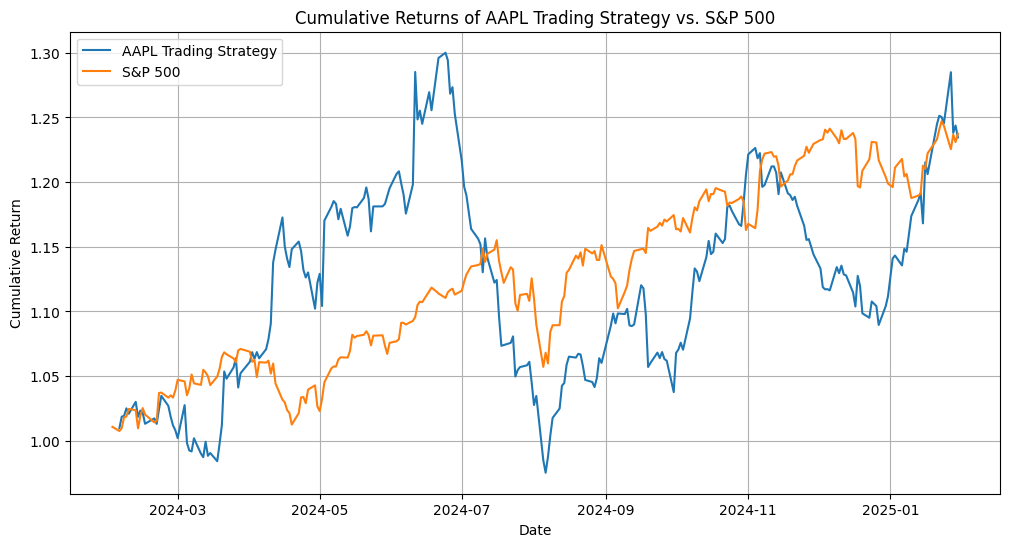

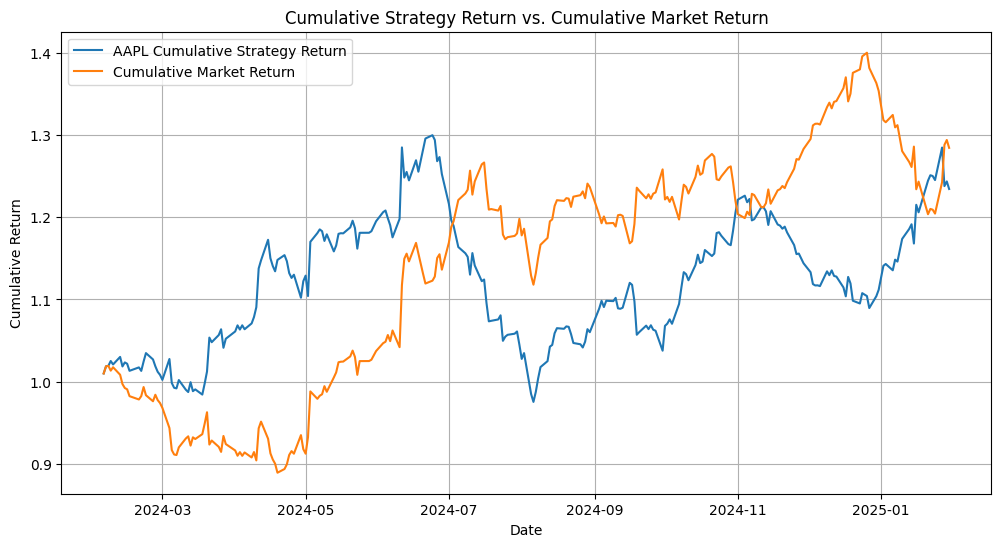

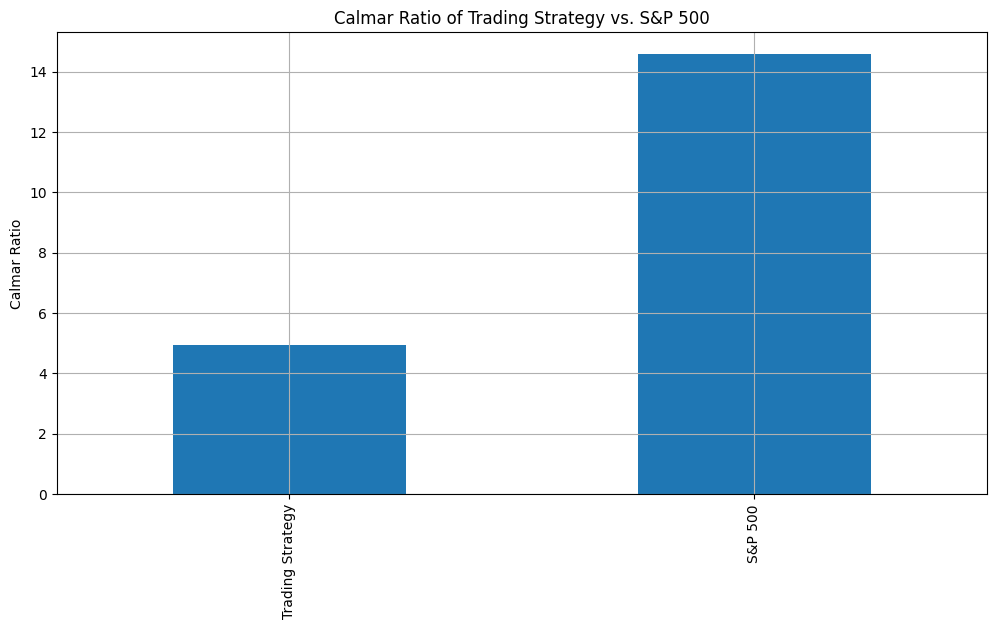

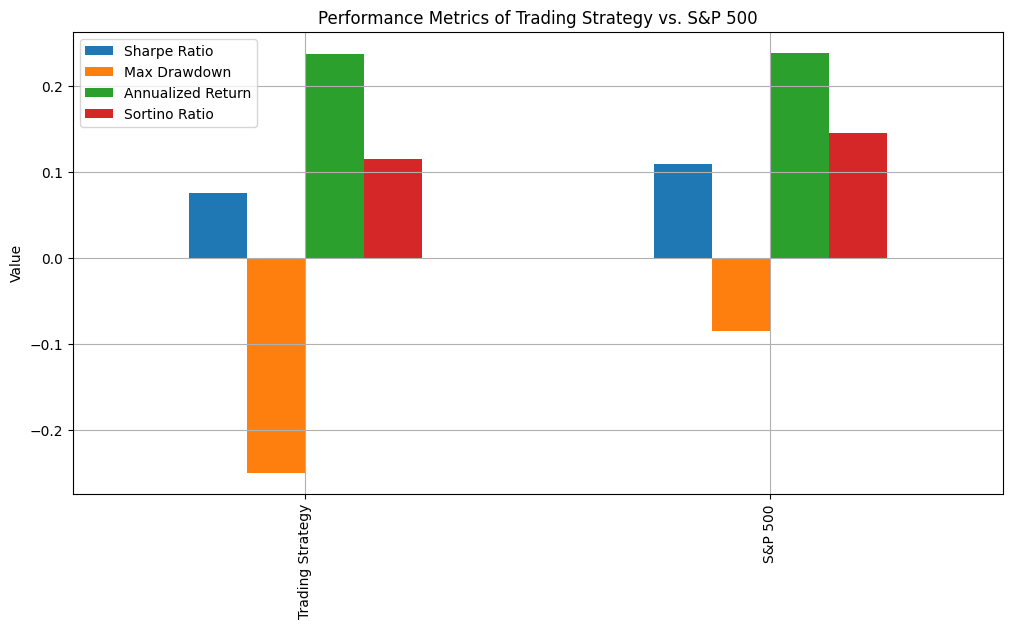

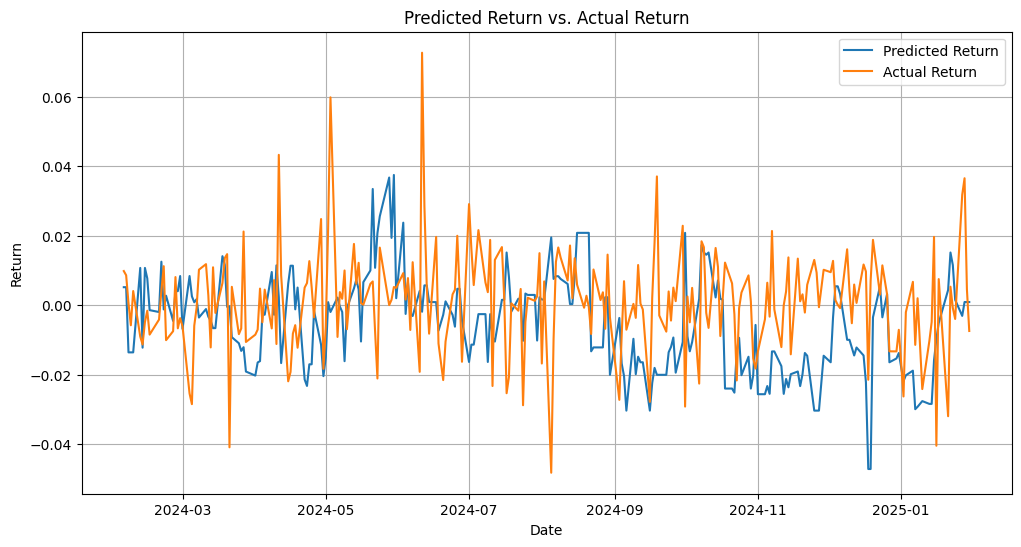

In [10]:
# Plot the cumulative returns of the trading strategy and the S&P 500
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(model_and_signals['Cumulative_Strategy_Return'], label=f'{ticker} Trading Strategy')
plt.plot(sp500_features['Cumulative_Market_Return'], label='S&P 500')
plt.legend()
plt.title(f'Cumulative Returns of {ticker} Trading Strategy vs. S&P 500')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid()
plt.show()

# Plot the cumulative strategy return and market return
plt.figure(figsize=(12, 6))
plt.plot(model_and_signals['Cumulative_Strategy_Return'], label=f'{ticker} Cumulative Strategy Return')
plt.plot(model_and_signals['Cumulative_Market_Return'], label='Cumulative Market Return')
plt.legend()
plt.title('Cumulative Strategy Return vs. Cumulative Market Return')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid()
plt.show()

# Create a bar chart comparing the Calmar ratio of the trading strategy and the S&P 500
performance_metrics_df['Calmar Ratio'].plot(kind='bar', figsize=(12, 6))
plt.title('Calmar Ratio of Trading Strategy vs. S&P 500')
plt.ylabel('Calmar Ratio')
plt.grid()
plt.show()


# Create a bar chart of the performance metrics, excluding the Calmar ratio
performance_metrics_df.drop('Calmar Ratio', axis=1).plot(kind='bar', figsize=(12, 6))
plt.title('Performance Metrics of Trading Strategy vs. S&P 500')
plt.ylabel('Value')
plt.grid()
plt.show()

# Plot the predicted return and actual return
plt.figure(figsize=(12, 6))
plt.plot(model_and_signals['Predicted_Return'], label='Predicted Return')
plt.plot(model_and_signals['Return'], label='Actual Return')
plt.legend()
plt.title('Predicted Return vs. Actual Return')
plt.xlabel('Date')
plt.ylabel('Return')
plt.grid()
plt.show()

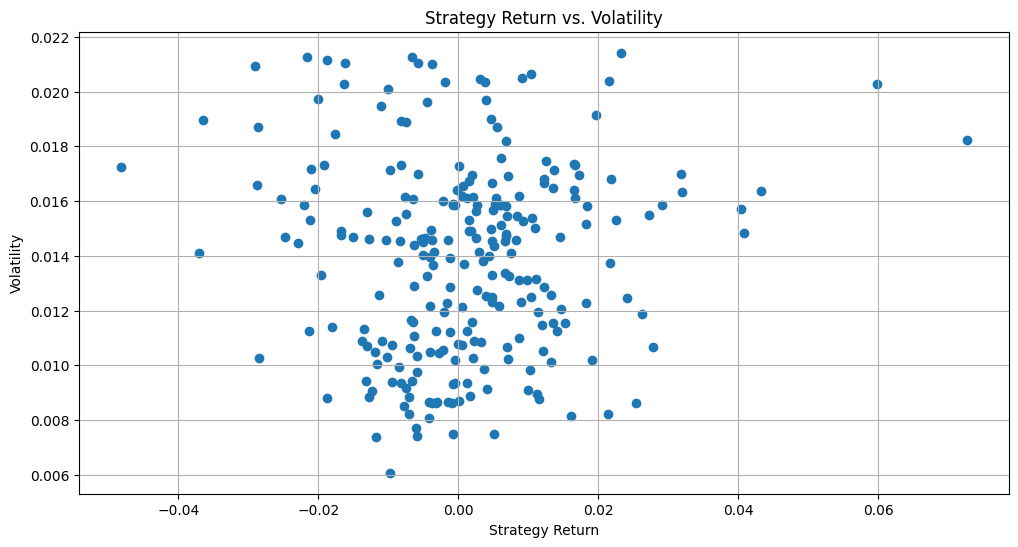

In [11]:
# Create candlestick chart for the new data
import plotly.graph_objects as go

fig = go.Figure(
    data=[go.Candlestick(x=new_features.index,
        open=new_features['Open'],
        high=new_features['High'],
        low=new_features['Low'],
        close=new_features['Close'])])
# label it
fig.update_layout(title=f'{ticker} Candlestick Chart',
                        xaxis_title='Date',
                        yaxis_title='Price')
fig.show()

# Create candlestick chart for the S&P 500 data
fig = go.Figure(
    data=[go.Candlestick(x=sp500_features.index,
        open=sp500_features['Open'],
        high=sp500_features['High'],
        low=sp500_features['Low'],
        close=sp500_features['Close'])])
# label it
fig.update_layout(title='S&P 500 Candlestick Chart',
                        xaxis_title='Date',
                        yaxis_title='Price')
fig.show()

# Create a scatter plot of the strategy return vs. the volatility
plt.figure(figsize=(12, 6))
plt.scatter(model_and_signals['Strategy_Return'], model_and_signals['Volatility'])
plt.title('Strategy Return vs. Volatility')
plt.xlabel('Strategy Return')
plt.ylabel('Volatility')
plt.grid()
plt.show()